# Projeto de Credit Score | Árvore de Decisão 


## Introdução
Realizamos no projeto de processamento e pré-modelagem dos dados, todos os tratamentos necessários para evoluir com a aplicação de modelos de aprendizado de máquina, desde transformação de variáveis categóricas até a separação de bases de treino e teste.

Fizemos também, alguns exercícios de aplicação de algoritmos de Naive Bayes para avaliar como o modelo se comporta na definição de score de crédito para uma amostra de clientes.

Neste projeto, aplicamos o algoritmo de de árvore de decisão para avaliar o seu comportamento na predição de score de crédito e comparar ele com os resultados obtidos no Naive Bayes.

Para ver mais sobre como foi aplicado o algoritimo Naive Bayes, consulte o projeto [aqui](https://github.com/Rafarosa/ciencia_de_dados_v2/blob/main/06%20-%20Primeiros%20modelos/03%20-%20Aprendizagem%20Baysiana/Projeto/Profissao%20Cientista%20de%20Dados%20M20%20Pratique.ipynb)


In [ ]:
#Bibliotecas necessárias para desenvolvimento do trabalho 

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

## Comece carregando as bases de treino (X e y) e teste (X e y).
Para iniciar a aplicação do modelo de árvore de decisão, vamos iniciar carregando os dados de treino e teste, previamente criados no pré-processamento. 

Onde X representam as variáveis preditoras e Y as variavel target, então termos bases de treino(X e Y) e variávesis de teste (X e Y)


In [ ]:
# Carregando as bases de treino e teste
X_test = pd.read_csv(r"Bases\X_test.csv", delimiter=',')
X_train = pd.read_csv(r"Bases\X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv(r"Bases\y_test.csv", delimiter=',')
y_train = pd.read_csv(r"Bases\y_train_balanced.csv", delimiter=',')

In [3]:
X_test

,Age,Income,Number of Children,Gender Encoded,Education Encoded,Marital Encoded,HomeOwnership Encoded
0,25,55000.0,0,0,1,1,1
1,48,87500.0,1,0,2,0,0
2,26,55000.0,1,0,1,0,0
3,39,62500.0,2,0,1,0,0
4,35,90000.0,1,0,2,0,0
5,25,55000.0,0,0,1,1,1
6,48,82500.0,1,0,2,0,0
7,48,82500.0,1,0,2,0,0
8,36,95000.0,2,0,4,0,0
9,37,95000.0,1,0,3,0,0


In [4]:
X_train

,Age,Income,Number of Children,Gender Encoded,Education Encoded,Marital Encoded,HomeOwnership Encoded
0,26,45000.000000,0,0,0,1,1
1,29,27500.000000,0,0,3,1,1
2,25,62500.000000,0,0,1,1,1
3,29,68000.000000,2,0,2,0,0
4,31,65000.000000,0,1,1,1,1
...,...,...,...,...,...,...,...
247,27,36803.652916,0,0,2,1,1
248,27,37500.000000,0,0,3,1,1
249,28,29946.263487,0,0,1,1,1
250,27,35412.944984,0,0,1,1,1


In [5]:
y_test

,CreditScore Encoded
0,0
1,1
2,0
3,1
4,1
5,0
6,1
7,1
8,1
9,1


In [6]:
y_train

,CreditScore Encoded
0,0
1,2
2,0
3,0
4,0
...,...
247,2
248,2
249,2
250,2


## Passos para aplicar de forma estruturada a árvore de decisão

**1 - Pré- processamento dos dados** 

Nessa etapa é importante, inicialmente, fazer a importação dos dados, seja por banco de dados, API ou como neste caso, realizando importação de arquivos CSV. Geralmente estamos usando a biblioteca pandas para esse fim.

Nesta etapa, também realizamos a limpeza de dados, onde podemos remover dados nulos duplicatas ou inconsistências. Neste caso, realizamos o tratamento de dados faltantes aplicando o valor da média e ajustamos os tipos de dados que melhor definem cada coluna dos dados. Identificação de outliers também deve ser visto nesta etapa.

Também é importante realizar a codificação de variáveis categóricas, elas ajudam a transformar os dados categóricos em dados numéricos para manipulação mais eficiente dos modelos. Utilizando Label Encoder ou one hot.

Após essa revisão dos dados podemos realizar a separação dos dados de treino e de teste com base na coluna predita. É muito importante realizar o balanceamento das bases de treino, para que o modelo tenha como analisar e aprender correlação entre os dados e com isso realizar uma avaliação mais ajustada em bases de teste quando solicitado. 

OBS: Não é obrigatório para a aplicação de modelos de LM  mas, é sempre de bom grado fazer análises exploratória com os dados obtidos como avaliação uni e bi lateral de dados, aferição dos dados para encontrar e trazer insights de suas descobertas.

**2 -  Construção do modelo**

A partir do momento em que todo o pré processamento foi realizado e deixamos os dados limpos e estruturados para a extração de dados de treino e teste, podemos aplicar em algum modelo, que neste caso é o modelo preditivo de árvore de decisão.

Nessa etapa podemos definir como podemos estruturar a árvore em função de classificação ou regressão, também podemos dimensionar o grau de complexidade da árvore como a profundidade máxima da árvore, número mínimo de amostras para dividir um nó e a medida de impureza.

**3 -  Avaliação do modelo**
Nesta etapa trazemos os dados de predição feita pelo modelo. É de suma importância que os mesmo não sejam analisados sozinhos, neste caso podemos trazer métricas de desempenho. Para avaliar o desempenho em função da classificação utilizamos acurácia, precisão(precision) recall , F1-score e matriz de confusão. Já para regressão podemos utilizar o R2 .

**Melhorando o modelo**
Para obter a melhora do modelo, podemos utilizar técnicas de poda, que consistem em definir limites da estrutura das nossas árvores, eliminando partes da árvore que podem ser julgadas desnecessárias ou que podem acarretar em overfitting. Os ajustes de hiperparâmetros também auxiliam nesta questão de melhora do modelo.


## Aplicando algoritmo de árvore de decisão aos dados de treinamento 

Porque aplicamos o Gini?

Tanto o índice de Gini quanto a entropia são medidas de impureza usadas em árvores de decisão para determinar a melhor forma de dividir os dados. O índice de Gini é geralmente mais rápido de calcular e por esse motivo usaremos esse índice em nosso modelo. 

Random_state= 0, qual o motivo?

significa que o desenvolvedor quer que os resultados do treinamento da árvore de decisão sejam exatamente os mesmos toda vez que o código for executado, eliminando a aleatoriedade como uma fonte de variação nos resultados. Isso é uma boa prática em machine learning para garantir a consistência e a capacidade de comparar experimentos de forma justa.


In [7]:
# Definindo o classificador
score_credit_classificador = DecisionTreeClassifier(criterion= 'gini', random_state= 0)

# consturindo o modelo com dados de treinamento
score_credit_classificador.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

Retornando os dados de acurácia da nase de treinamento

In [8]:
# Retorando a acurácia do modelo com a base de treinamento
previsao_scc_treinamento = score_credit_classificador.predict(X_train)
acuracia_scc_treinamento = accuracy_score(y_train, previsao_scc_treinamento)
print(f"Acurácia do modelo com a base de treinamento: {acuracia_scc_treinamento:.2%}")

# Criando relatório de classificação da base de treinamento
relatorio_treinamento = classification_report(y_train, previsao_scc_treinamento)
print("Relatório de Classificação - Base de Treinamento:\n", relatorio_treinamento)

Acurácia do modelo com a base de treinamento: 100.00%
Relatório de Classificação - Base de Treinamento:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        84
           1       1.00      1.00      1.00        84
           2       1.00      1.00      1.00        84

    accuracy                           1.00       252
   macro avg       1.00      1.00      1.00       252
weighted avg       1.00      1.00      1.00       252



## Aplicando o modelo aos dados de teste e trazendo um relatório de classificação 

In [9]:
# Retorando a acurácia do modelo com a base de teste
previsao_scc_test = score_credit_classificador.predict(X_test)
acuracia_scc_test = accuracy_score(y_test, previsao_scc_test)
print(f"Acurácia do modelo com a base de teste: {acuracia_scc_test:.2%}")

Acurácia do modelo com a base de teste: 97.56%


In [10]:
# Criando relatório de classificação da base de teste
relatorio_teste = classification_report(y_test, previsao_scc_test)
print("Relatório de Classificação - Base de Teste:\n", relatorio_teste)

Relatório de Classificação - Base de Teste:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.97      0.98        29
           2       1.00      1.00      1.00         6

    accuracy                           0.98        41
   macro avg       0.95      0.99      0.97        41
weighted avg       0.98      0.98      0.98        41



## Avaliação do desemprenho da base de treino e teste do modelo

Sobre a base de treinamento, O modelo está overfitting. Ele memorizou perfeitamente os dados de treinamento, conseguindo classificar todas as 252 amostras sem nenhum erro. Isso é esperado para uma árvore de decisão que não teve sua profundidade ou complexidade limitada, pois ela pode crescer até um ponto em que cada folha representa um ou um pequeno grupo de pontos de dados de treinamento.

A acurácia de 98% no conjunto de teste é muito alta e indica que o modelo está generalizando muito bem para dados não vistos, apesar do overfitting no treinamento.

Tanto a base de treino quanto a base de teste estão apresentando uma acurácia muito elevada. Assim como a métrica precision , recall e f1-score para todos as classes da nossa variavel target.

Contudo, essa perfeição em cenários reais, são muito difíceis de conseguir, o que pode salientar as questões de overfitting. Isso se deve muito ao tamanho do conjunto de treino e teste.

A árvore de decisão tem uma capacidade de expandir até certo ponto, depois disso ela pode ter um desempenho muito abaixo do esperado  em relação a capacidade de memorização de dados da base de treino.

Analisando o conjunto de testes, temos apenas 41 amostra, podendo não ser o suficiente para acompanhar a complexidade de dados em um mundo real. Provavelmente, com dados de teste diferenciados e em maior quantidade, tenhamos um desempenho muito inferior.

Outro fator que pode contribuir com esses resultados é a qualidade dos dados, os dados são de fácil classificação e estão muito bem separados por features que, pela análise feita nos módulos anteriores, existem features altamente preditivas, ou seja, são muito determinísticas para definição de score de crédito. facilitando muito a compreensão dos dados e determinação de score.

## Plote da árvore de decisão.

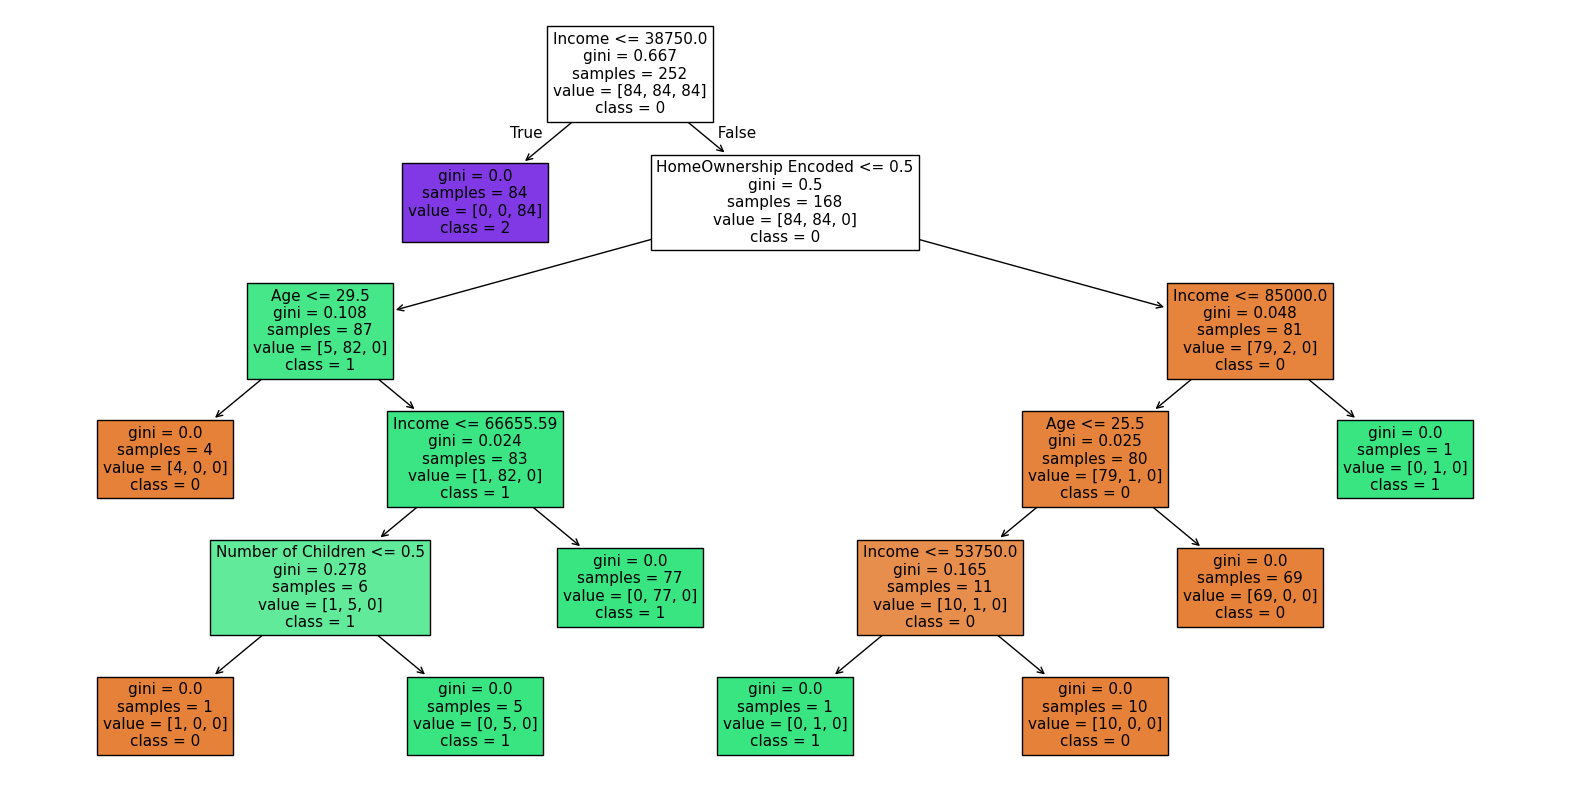

In [11]:
#plotando a árvore de decisão
plt.figure(figsize=(20,10))
plot_tree(score_credit_classificador, filled=True, feature_names=X_train.columns, class_names=['0', '1', '2'], fontsize=11)
plt.show()

**Avaliação visual da árvore**

Conseguimos ter uma visualização bem clara das classes envolvidas no treinamento do modelo. Essa árvore apresenta uma profundidade de 5 níveis (Raiz e mais 5 divisões)

Podemos predizer que a classe mais importante para iniciarmos a árvore de decisão é o `Income`, a partir dela serão avaliados os outros denominadores de classificação

observando que temos na raiz um gini de 0.66, com 252 exemplos de treino neste nó, divididos em 3 classes (0, 1, 2) que representa o score de crédito de cada indivíduo da amostra.


## Identifique as 2 principais features do modelo.

A identificação das features principais do modelo, auxilia em muitos caso a melhorar o desempenho do algoritmo


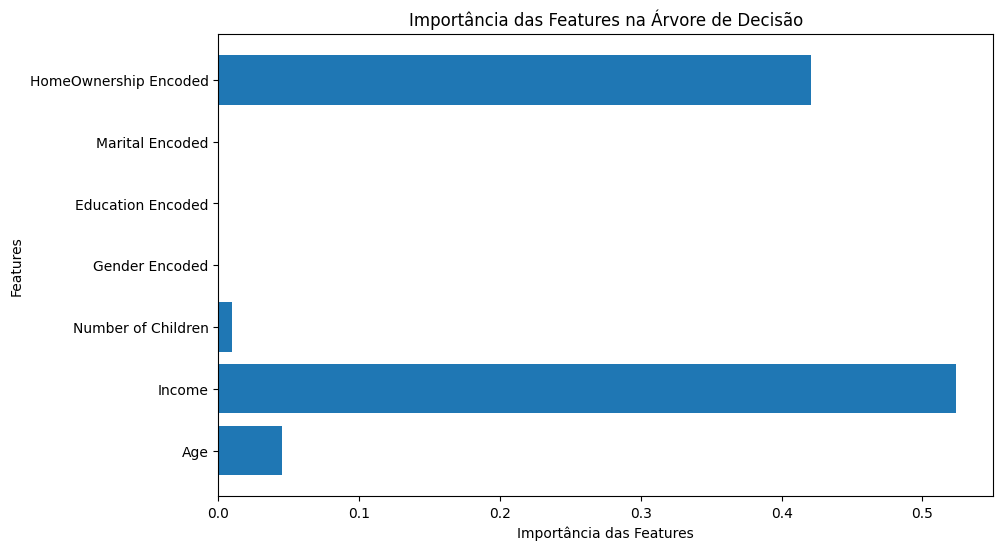

In [12]:
# Obtendo a importância das características do modelo de árvore de decisão
importancias_features = score_credit_classificador.feature_importances_

# Obtendo os nomes das características
nomes_features = X_train.columns

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, importancias_features)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

## Rodando um modelo de árvore de de decisão com as features encontradas anteriormente, e na sequência avaliamos os resultados  

In [13]:
# Refinamento da estrutura da árvore com dados ajustafos em função da importância das features
X_train_refinado = X_train[['Income', 'HomeOwnership Encoded']]
X_test_refinado = X_test[['Income', 'HomeOwnership Encoded']]

In [14]:
# Definindo o classificador Filtrado
score_credit_classificador_filtrado = DecisionTreeClassifier(criterion= 'gini', random_state= 0)

# consturindo o modelo com dados de treinamento
score_credit_classificador_filtrado.fit(X_train_refinado, y_train)

DecisionTreeClassifier(random_state=0)

In [15]:
# criando variavel de previsão com dados refinados
previsao_scc_filtrado = score_credit_classificador_filtrado.predict(X_test_refinado)

In [16]:
# Criando relatório de classificação da base de teste refinada
relatorio_teste_filtrado = classification_report(y_test, previsao_scc_filtrado)

In [17]:
print("Relatório de Classificação:")
print(relatorio_teste_filtrado)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.97      0.97      0.97        29
           2       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



Avaliação

Ao comparar os resultados dos modelos com e sem filtro de features, podemos observar que houve uma piora nas métricas de avaliação dos resultados.

- Precision
Classe 0 = 83% das amostras previstas como pertencentes à classe 0 realmente são da classe 0
Classe 1 = 97% das amostras previstas como pertencentes à classe 0 realmente são da classe 1
Classe 2 = 100% das amostras previstas como pertencentes à classe 0 realmente são da classe 2

- F1-Score
Classe 0 = Apresenta média harmônica da Precisão de 83% das amostras pertencentes à classe 0 realmente são da classe 0
Classe 1 = Apresenta média harmônica da Precisão de 97% das amostras pertencentes à classe 0 realmente são da classe 0
Classe 2 = Apresenta média harmônica da Precisão de 100% das amostras pertencentes à classe 0 realmente são da classe 0

- Recall
Classe 0 = 83%,indicando que o modelo identificou corretamente 83% das amostras da classe 0.
Classe 1 = 97%, ,indicando que o modelo identificou corretamente 97% das amostras da classe 1.
Classe 2 = 100%,indicando que o modelo identificou corretamente 100% das amostras da classe 2.


A acurácia global foi de 95%, o que significa que a previsão do modelo está correta em 95% das predições

Macro Average: Apresenta media simples das méticas apresenta o valor de 93%

Weighted Average: Apresenta a média ponderada das métricas apresenta o valor de 95%

Isso ocorre pois ao eliminar uma feature de menor importância, ela continha informações importantes e discriminatórias para a árvore de decisão, forçando o modelo a se ajustar com poucos parâmetros de observação. Esse comportamento evidencia a interatividade de mais de uma feature no contexto geral do modelo.
Repetindo novamente, o tamanho da base também reflete nos resultados obtidos por ser de uma base pequena.


##  Análise final sobre resultados óbitos na árvore de decisão em os resultados de Naive Bayes 

**Comparando resultados**

Comparando os dados sem qualquer filtragem (Como ocorreu no modelo de arvore de decisão). ***A Árvore de decisão apresentou um melhor resultado das avaliações***, podendo realizar previsão com 100% de assertividade na base de teste, pois Constrói uma estrutura de árvore hierárquica onde cada nó interno representa um teste em uma feature, cada ramo representa o resultado desse teste, e cada nó folha representa uma classe de decisão. O algoritmo busca divisões que maximizem a pureza das classes (minimizar a impureza Gini ou entropia).


A árvore de decisão também tem uma característica, ser capaz de capturar iteração sobre as features (Como vimos ao realizar um filtro de features no questionamento 7) validando cada feature em conjunto (Diferente de Naive Bayes que assume que cada feature é independente), também pela possibilidade de ter uma estrutura visual de regras, ou seja, tem uma alta interpretabilidade.


Porém, é extremamente importante ressaltar que isso não é uma regra, pois o modelo de árvore de decisão apresenta uma alta propensão de Overfitting se não ocorrer podas na estrutura e ser muito sensível a outliers caso a base não seja previamente analisada.
